# Navigation Log Analysis

Visualize CSV logs from `app.py` to debug rotation issues (especially E-W travel).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

LOG_DIR = Path("nav_logs")

# Load the latest CSV, or set a specific path here
csv_files = sorted(LOG_DIR.glob("*.csv"))
csv_path = csv_files[-1] if csv_files else None
print(f"Loading: {csv_path}")

df = pd.read_csv(csv_path)
df.index.name = "row"
print(f"{len(df)} rows, events: {df['event'].value_counts().to_dict()}")
df.head(10)

## Event Timeline

Overview of what happened: detections, turns, moves.

In [8]:
non_frame = df[df["event"] != "MOVE_FRAME"].copy()
cols = ["t", "event", "cell", "facing", "heading_offset",
        "aruco_id", "aruco_angle", "turn_cmd", "turn_deg", "d_mm"]
non_frame[cols].fillna("")

,t,event,cell,facing,heading_offset,aruco_id,aruco_angle,turn_cmd,turn_deg,d_mm
row,,,,,,,,,,
0,17:29:59.038,PLAN,0,SOUTH,180.0,,,-1.0,-90.0,
1,17:29:59.039,PLAN,0,SOUTH,180.0,,,,,1000.0
2,17:29:59.039,TURN_START,0,EAST,90.0,,,-1.0,-90.0,
3,17:30:01.713,TURN_DONE,0,EAST,90.0,,,,,
172,17:30:07.234,MOVE_DONE,0,EAST,90.0,,,,,994.0


## ArUco Angle + Line Angle Over Time

Top: raw ArUco angle from detector. Bottom: fused line angle (after heading_offset subtraction).
If line_angle oscillates wildly during a move, that's the spinning signal.

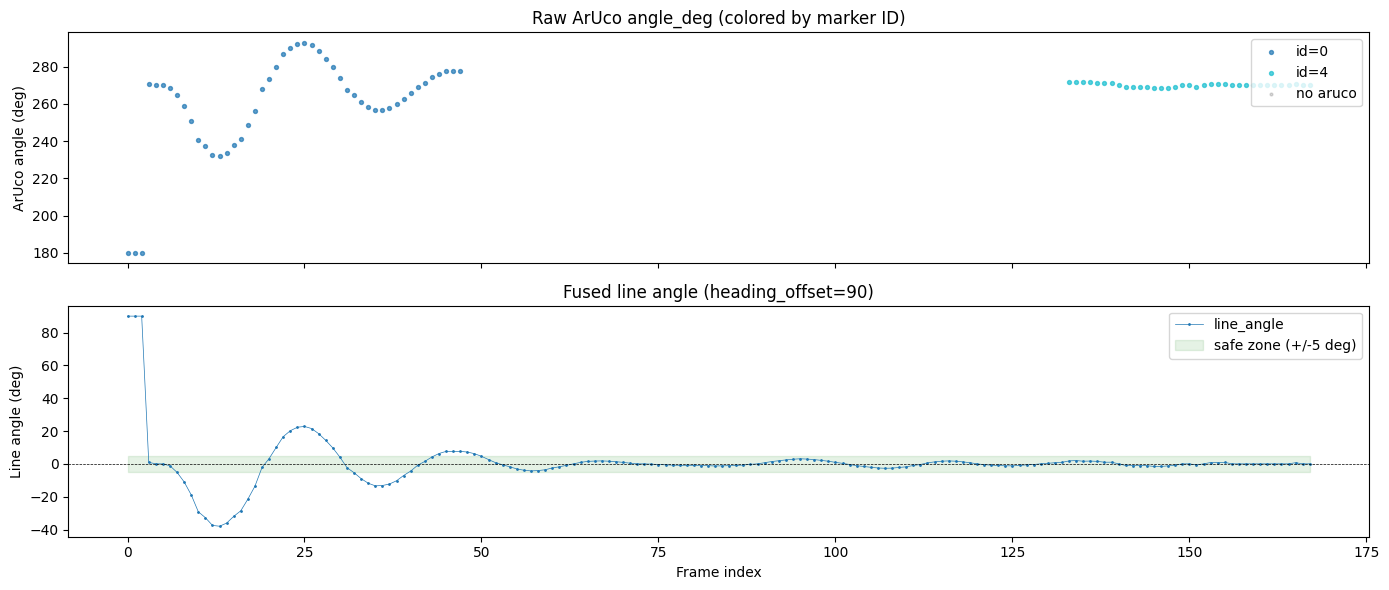

In [9]:
mf = df[df["event"] == "MOVE_FRAME"].copy().reset_index(drop=True)
mf["aruco_angle"] = pd.to_numeric(mf["aruco_angle"], errors="coerce")
mf["aruco_id"] = pd.to_numeric(mf["aruco_id"], errors="coerce")
mf["line_angle"] = pd.to_numeric(mf["line_angle"], errors="coerce")
mf["heading_offset"] = pd.to_numeric(mf["heading_offset"], errors="coerce")
mf["has_aruco"] = mf["aruco_angle"].notna()

if len(mf) == 0:
    print("No MOVE_FRAME data found.")
else:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # ArUco raw angle, colored by marker ID
    aruco_rows = mf[mf["has_aruco"]]
    unique_ids = sorted(aruco_rows["aruco_id"].dropna().unique())
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_ids), 1)))
    id_color = {mid: colors[i] for i, mid in enumerate(unique_ids)}

    for mid in unique_ids:
        mask = aruco_rows["aruco_id"] == mid
        ax1.scatter(aruco_rows.index[mask], aruco_rows.loc[mask, "aruco_angle"],
                    s=8, alpha=0.7, color=id_color[mid], label=f"id={int(mid)}")
    no_aruco = mf[~mf["has_aruco"]]
    if len(no_aruco) > 0:
        ax1.scatter(no_aruco.index, [None] * len(no_aruco),
                    s=4, alpha=0.3, c="gray", label="no aruco")
    ax1.set_ylabel("ArUco angle (deg)")
    ax1.legend(loc="upper right")
    ax1.set_title("Raw ArUco angle_deg (colored by marker ID)")

    # Fused line angle
    has_line = mf["line_angle"].notna()
    ax2.plot(mf.index[has_line], mf.loc[has_line, "line_angle"],
             ".-", ms=2, lw=0.5, label="line_angle")
    ax2.axhline(0, color="k", ls="--", lw=0.5)
    ax2.fill_between(mf.index, -5, 5, alpha=0.1, color="green", label="safe zone (+/-5 deg)")
    ax2.set_ylabel("Line angle (deg)")
    ax2.set_xlabel("Frame index")
    ax2.legend(loc="upper right")
    ho = mf["heading_offset"].iloc[0]
    ax2.set_title(f"Fused line angle (heading_offset={ho:.0f})")

    plt.tight_layout()
    plt.show()

## Wheel Velocities (lv, rv)

If lv and rv diverge (large gap) the robot is turning hard. Shaded area = lv - rv (turning rate).

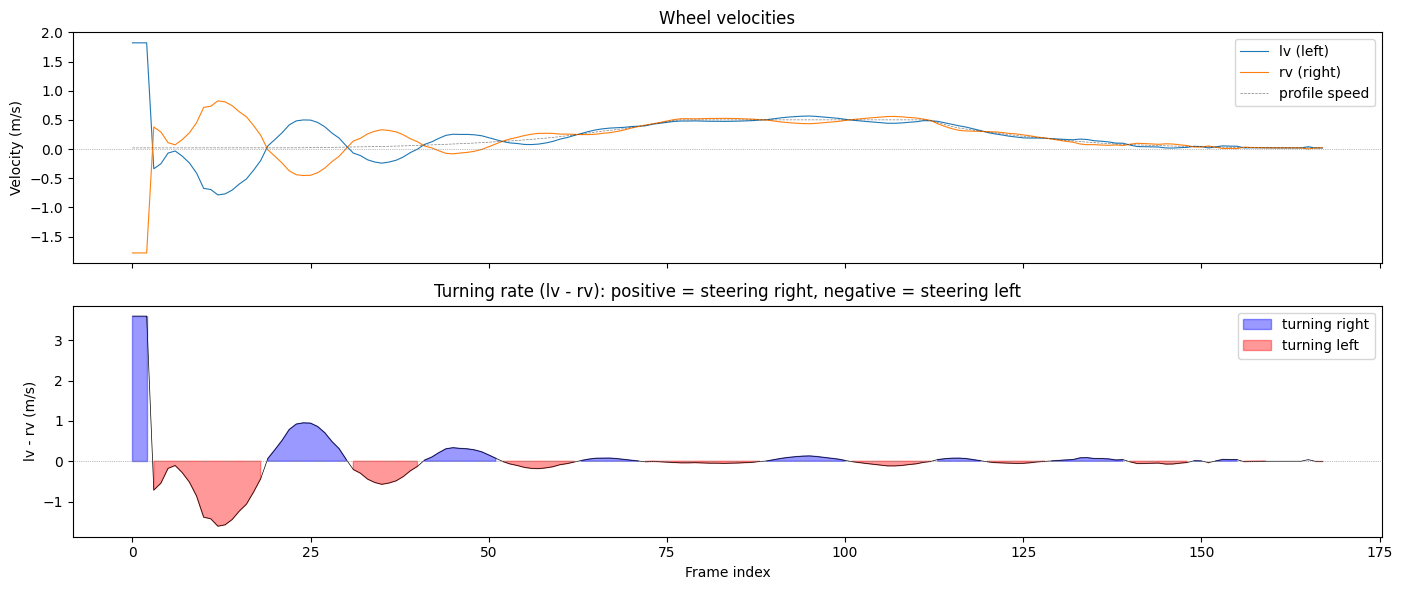

In [10]:
if len(mf) == 0:
    print("No MOVE_FRAME data found.")
else:
    mf["lv"] = pd.to_numeric(mf["lv"], errors="coerce")
    mf["rv"] = pd.to_numeric(mf["rv"], errors="coerce")
    mf["speed"] = pd.to_numeric(mf["speed"], errors="coerce")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Wheel velocities
    ax1.plot(mf.index, mf["lv"], label="lv (left)", lw=0.8)
    ax1.plot(mf.index, mf["rv"], label="rv (right)", lw=0.8)
    ax1.plot(mf.index, mf["speed"], "k--", label="profile speed", lw=0.5, alpha=0.5)
    ax1.axhline(0, color="gray", ls=":", lw=0.5)
    ax1.set_ylabel("Velocity (m/s)")
    ax1.legend(loc="upper right")
    ax1.set_title("Wheel velocities")

    # Turning rate (lv - rv)
    diff = mf["lv"] - mf["rv"]
    ax2.fill_between(mf.index, 0, diff, where=diff > 0, alpha=0.4, color="blue", label="turning right")
    ax2.fill_between(mf.index, 0, diff, where=diff < 0, alpha=0.4, color="red", label="turning left")
    ax2.plot(mf.index, diff, lw=0.5, color="black")
    ax2.axhline(0, color="gray", ls=":", lw=0.5)
    ax2.set_ylabel("lv - rv (m/s)")
    ax2.set_xlabel("Frame index")
    ax2.legend(loc="upper right")
    ax2.set_title("Turning rate (lv - rv): positive = steering right, negative = steering left")

    plt.tight_layout()
    plt.show()

## Heading Offset Math: aruco_angle vs line_angle

Shows the `(aruco_angle - heading_offset) % 180` transformation.
Points should cluster near 0 on the y-axis. Outliers = bad corrections.

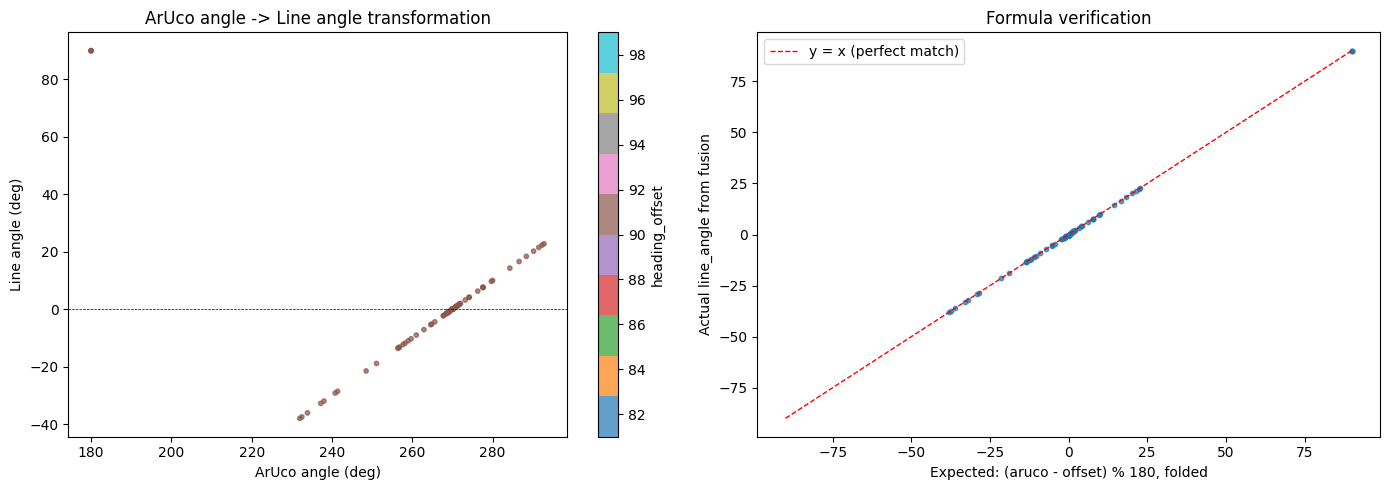

In [11]:
aruco_frames = mf[mf["has_aruco"]].copy()

if len(aruco_frames) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: aruco_angle vs line_angle
    sc = ax1.scatter(aruco_frames["aruco_angle"], aruco_frames["line_angle"],
                     c=aruco_frames["heading_offset"], cmap="tab10",
                     s=10, alpha=0.7)
    ax1.set_xlabel("ArUco angle (deg)")
    ax1.set_ylabel("Line angle (deg)")
    ax1.axhline(0, color="k", ls="--", lw=0.5)
    ax1.set_title("ArUco angle -> Line angle transformation")
    plt.colorbar(sc, ax=ax1, label="heading_offset")

    # Verify the math: recompute (aruco - offset) % 180 and compare
    expected = (aruco_frames["aruco_angle"] - aruco_frames["heading_offset"]) % 180
    expected = expected.where(expected <= 90, expected - 180)
    ax2.scatter(expected, aruco_frames["line_angle"], s=10, alpha=0.7)
    ax2.plot([-90, 90], [-90, 90], "r--", lw=1, label="y = x (perfect match)")
    ax2.set_xlabel("Expected: (aruco - offset) % 180, folded")
    ax2.set_ylabel("Actual line_angle from fusion")
    ax2.set_title("Formula verification")
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No frames with ArUco detection found.")

## Per-Segment Breakdown

Each MOVE segment plotted separately. Compare N-S (stable) vs E-W (potentially spinning).

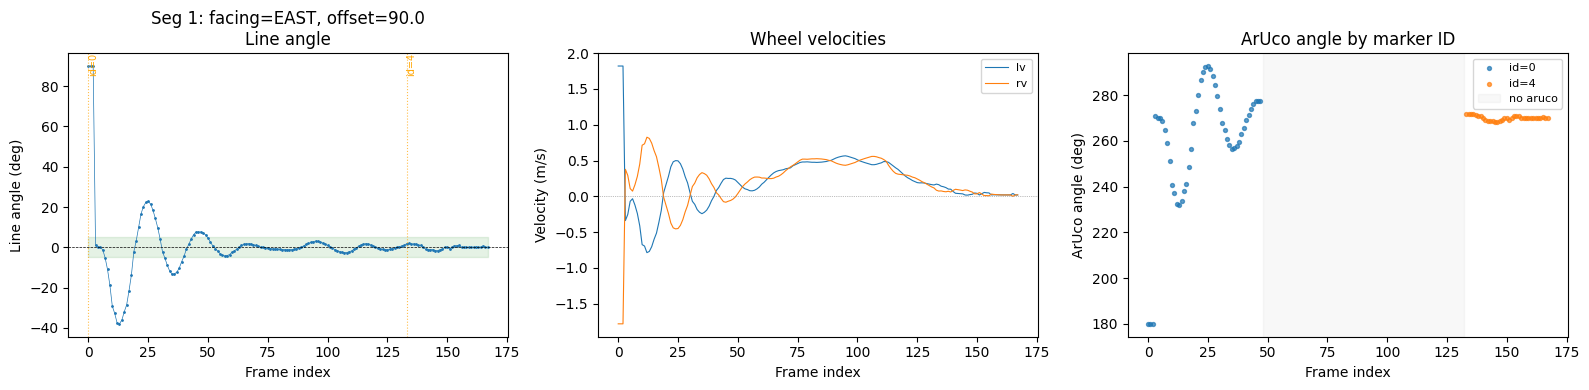

In [12]:
# Split MOVE_FRAME rows into segments (separated by non-MOVE_FRAME events)
segments = []
current = []
for _, row in df.iterrows():
    if row["event"] == "MOVE_FRAME":
        current.append(row)
    else:
        if current:
            segments.append(pd.DataFrame(current).reset_index(drop=True))
            current = []
if current:
    segments.append(pd.DataFrame(current).reset_index(drop=True))

n_seg = len(segments)
if n_seg == 0:
    print("No MOVE segments found.")
else:
    fig, axes = plt.subplots(n_seg, 3, figsize=(16, 4 * n_seg), squeeze=False)

    for i, seg in enumerate(segments):
        for col in ["line_angle", "lv", "rv", "d_mm", "aruco_angle", "aruco_id"]:
            seg[col] = pd.to_numeric(seg[col], errors="coerce")

        facing = seg["facing"].iloc[0]
        ho = seg["heading_offset"].iloc[0]
        title = f"Seg {i+1}: facing={facing}, offset={ho}"

        # Line angle + aruco_id annotations
        ax = axes[i][0]
        has_line = seg["line_angle"].notna()
        ax.plot(seg.index[has_line], seg.loc[has_line, "line_angle"], ".-", ms=2, lw=0.5)
        ax.axhline(0, color="k", ls="--", lw=0.5)
        ax.fill_between(seg.index, -5, 5, alpha=0.1, color="green")
        # Mark where aruco ID changes
        has_aruco = seg["aruco_id"].notna()
        unique_ids = sorted(seg.loc[has_aruco, "aruco_id"].unique())
        for mid in unique_ids:
            mask = seg["aruco_id"] == mid
            first_idx = seg.index[mask][0]
            ax.axvline(first_idx, color="orange", ls=":", lw=0.8, alpha=0.7)
            ax.annotate(f"id={int(mid)}", (first_idx, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 5),
                        fontsize=7, color="orange", rotation=90, va="top")
        ax.set_ylabel("Line angle (deg)")
        ax.set_title(f"{title}\nLine angle")

        # Wheel velocities
        ax = axes[i][1]
        ax.plot(seg.index, seg["lv"], label="lv", lw=0.8)
        ax.plot(seg.index, seg["rv"], label="rv", lw=0.8)
        ax.axhline(0, color="gray", ls=":", lw=0.5)
        ax.set_ylabel("Velocity (m/s)")
        ax.legend(fontsize=8)
        ax.set_title("Wheel velocities")

        # ArUco angle colored by ID
        ax = axes[i][2]
        for mid in unique_ids:
            mask = seg["aruco_id"] == mid
            ax.scatter(seg.index[mask], seg.loc[mask, "aruco_angle"],
                       s=8, alpha=0.7, label=f"id={int(mid)}")
        no_a = seg[~has_aruco]
        if len(no_a) > 0:
            ax.axvspan(no_a.index[0], no_a.index[-1], alpha=0.05, color="gray", label="no aruco")
        ax.set_ylabel("ArUco angle (deg)")
        ax.legend(fontsize=8)
        ax.set_title("ArUco angle by marker ID")

    for ax in axes[-1]:
        ax.set_xlabel("Frame index")

    plt.tight_layout()
    plt.show()